In [6]:
import pickle
import torch
from tqdm import tqdm
from minf.data import FieldPDBDataset
from minf.models import Autoencoder, SirenNet, Decoder, SirenNetUnbatched
from minf.utils import plot_field
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [13]:
resolution = 32
rotation = 270

fd = FieldPDBDataset("../data/1osl.pdb", resolution=resolution, single_property=9)
dl = DataLoader(fd, batch_size=1, shuffle=True)
dl_test = DataLoader(fd, batch_size=1, shuffle=False)

In [14]:
for batch in dl_test:
    for field in batch:
        ...#plot_field(field[:, :, :, 0], cam_rotate=rotation).show()

In [16]:
net = SirenNetUnbatched(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

decoder = Decoder(
    net,
    # output_shape=[resolution, resolution, resolution, 24, 1],
    output_shape=[resolution, resolution, resolution, 1, 1],
    latent_dim=128,
    n_shapes=len(dl_test)
)

decoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=decoder.parameters())

In [33]:
min_loss = 9999999
for epoch in (pbar := tqdm(range(20000))):
    for i, batch in enumerate(dl_test):
        total_loss = 0
        for field in batch:
            loss = decoder(field.cuda(), latent_idx=i)
            optim.zero_grad()
            loss.backward()
            optim.step()
            total_loss += loss.item()

    avg_loss = total_loss / len(dl_test)
        
    if avg_loss < min_loss:
        min_loss = avg_loss
        torch.save(decoder.state_dict(), "multishape_model.pt")
            
    pbar.set_description(f"Epoch {epoch} (loss: {avg_loss})")
    continue

Epoch 66 (loss: 0.00045451195910573006):   0%|▏                                                         | 67/20000 [00:22<1:50:41,  3.00it/s]


KeyboardInterrupt: 

yt : [INFO     ] 2025-02-12 00:30:39,074 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 00:30:39,075 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 00:30:39,075 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 00:30:39,075 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 00:30:39,075 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 00:30:39,118 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 00:30:39,124 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 00:30:39,125 Creating volume
yt : [INFO     ] 2025-02-12 00:30:39,141 Creating transfer function
yt : [INFO     ] 2025-02-12 00:30:39,142 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


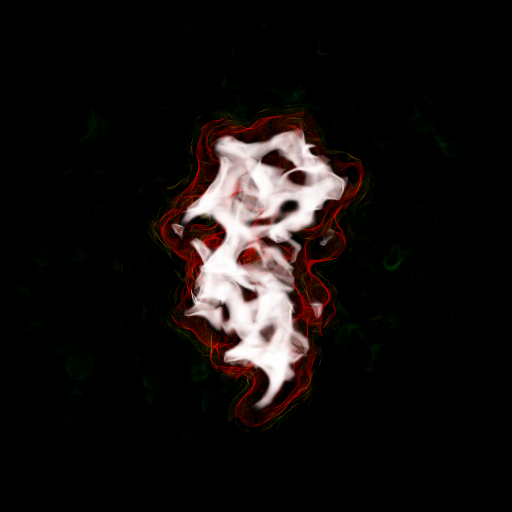

In [26]:
field = reconstructed = decoder(None, latent_idx=0)
field = field.cpu().detach().squeeze(-1)
plot_field(field[:, :, :, 0]).show()

In [27]:
def interp(arr1, arr2, num_points):
    fractions = np.linspace(0, 1, num_points)
    return np.array([arr1 + (arr2 - arr1) * f for f in fractions])

yt : [INFO     ] 2025-02-12 00:36:08,172 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 00:36:08,172 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 00:36:08,173 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 00:36:08,173 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 00:36:08,173 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 00:36:08,216 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 00:36:08,223 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 00:36:08,223 Creating volume
yt : [INFO     ] 2025-02-12 00:36:08,240 Creating transfer function
yt : [INFO     ] 2025-02-12 00:36:08,240 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


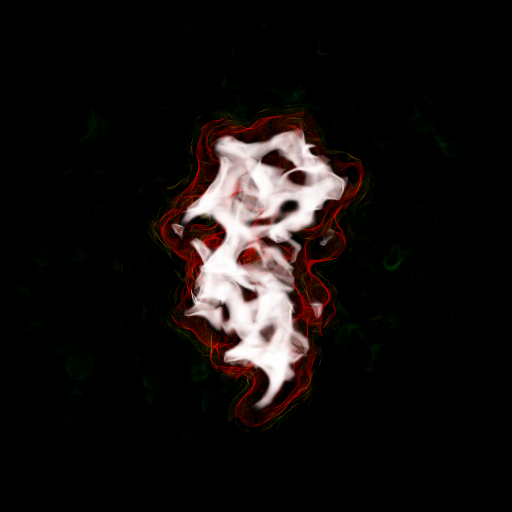

yt : [INFO     ] 2025-02-12 00:36:08,417 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 00:36:08,417 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 00:36:08,417 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 00:36:08,417 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 00:36:08,418 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 00:36:08,459 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 00:36:08,465 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 00:36:08,466 Creating volume
yt : [INFO     ] 2025-02-12 00:36:08,482 Creating transfer function
yt : [INFO     ] 2025-02-12 00:36:08,482 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


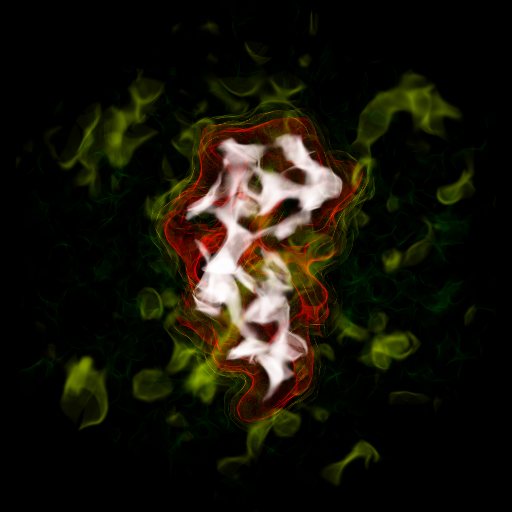

yt : [INFO     ] 2025-02-12 00:36:08,726 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 00:36:08,726 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 00:36:08,727 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 00:36:08,727 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 00:36:08,727 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 00:36:08,768 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 00:36:08,774 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 00:36:08,775 Creating volume
yt : [INFO     ] 2025-02-12 00:36:08,790 Creating transfer function
yt : [INFO     ] 2025-02-12 00:36:08,790 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


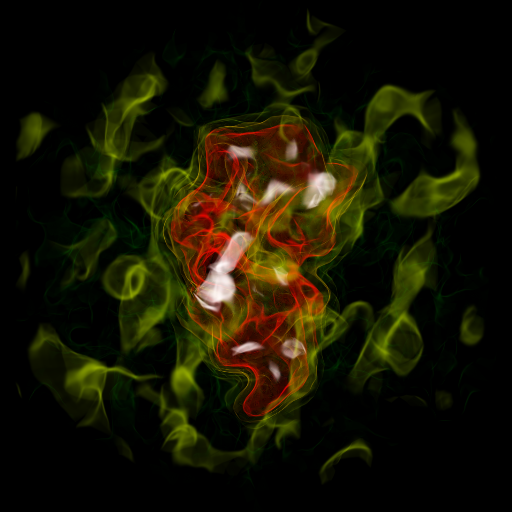

yt : [INFO     ] 2025-02-12 00:36:09,042 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 00:36:09,042 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 00:36:09,042 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 00:36:09,043 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 00:36:09,043 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 00:36:09,082 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 00:36:09,088 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 00:36:09,089 Creating volume
yt : [INFO     ] 2025-02-12 00:36:09,105 Creating transfer function
yt : [INFO     ] 2025-02-12 00:36:09,105 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


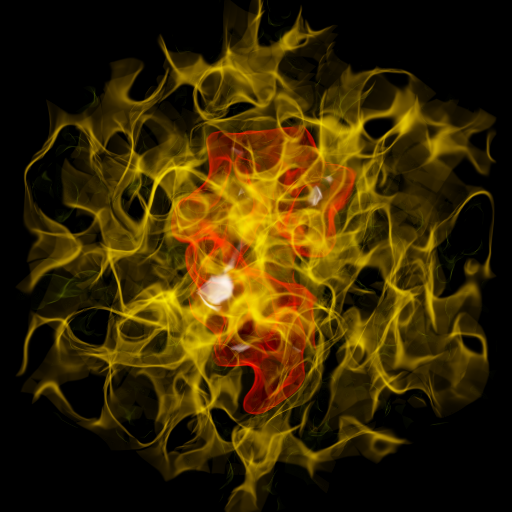

yt : [INFO     ] 2025-02-12 00:36:09,434 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 00:36:09,434 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 00:36:09,435 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 00:36:09,435 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 00:36:09,435 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 00:36:09,475 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 00:36:09,482 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 00:36:09,483 Creating volume
yt : [INFO     ] 2025-02-12 00:36:09,499 Creating transfer function
yt : [INFO     ] 2025-02-12 00:36:09,499 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


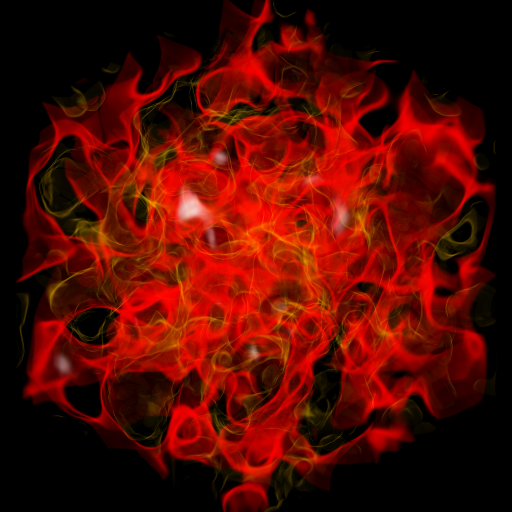

yt : [INFO     ] 2025-02-12 00:36:09,725 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 00:36:09,725 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 00:36:09,725 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 00:36:09,725 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 00:36:09,726 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 00:36:09,766 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 00:36:09,773 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 00:36:09,773 Creating volume
yt : [INFO     ] 2025-02-12 00:36:09,789 Creating transfer function
yt : [INFO     ] 2025-02-12 00:36:09,789 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


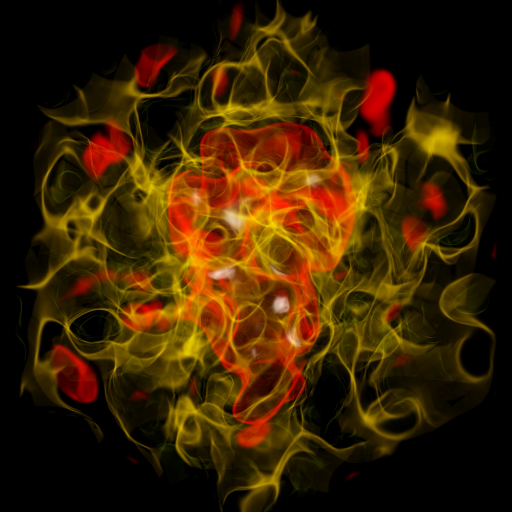

yt : [INFO     ] 2025-02-12 00:36:10,057 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 00:36:10,057 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 00:36:10,057 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 00:36:10,057 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 00:36:10,057 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 00:36:10,097 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 00:36:10,104 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 00:36:10,104 Creating volume
yt : [INFO     ] 2025-02-12 00:36:10,120 Creating transfer function
yt : [INFO     ] 2025-02-12 00:36:10,121 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


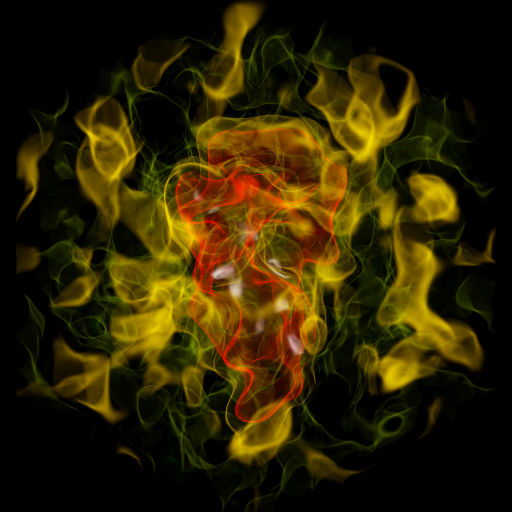

yt : [INFO     ] 2025-02-12 00:36:10,461 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 00:36:10,462 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 00:36:10,462 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 00:36:10,462 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 00:36:10,463 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 00:36:10,503 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 00:36:10,509 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 00:36:10,510 Creating volume
yt : [INFO     ] 2025-02-12 00:36:10,525 Creating transfer function
yt : [INFO     ] 2025-02-12 00:36:10,526 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


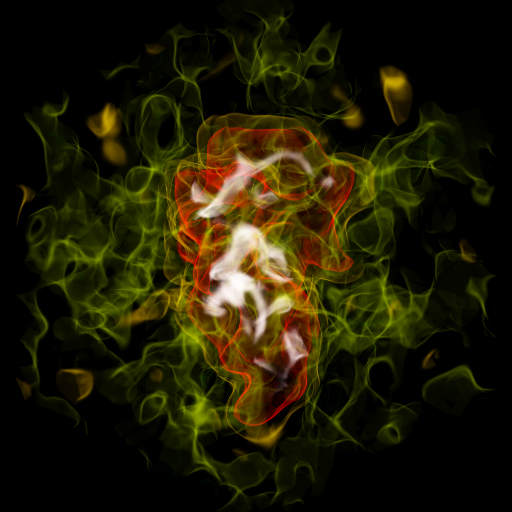

yt : [INFO     ] 2025-02-12 00:36:10,790 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 00:36:10,790 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 00:36:10,791 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 00:36:10,791 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 00:36:10,791 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 00:36:10,833 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 00:36:10,839 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 00:36:10,840 Creating volume
yt : [INFO     ] 2025-02-12 00:36:10,856 Creating transfer function
yt : [INFO     ] 2025-02-12 00:36:10,856 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


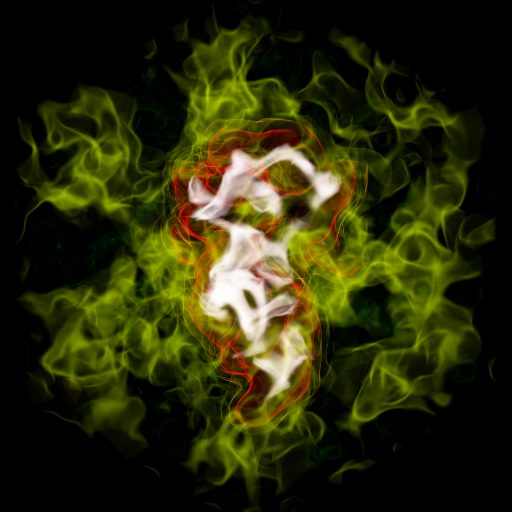

yt : [INFO     ] 2025-02-12 00:36:11,184 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 00:36:11,184 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 00:36:11,184 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 00:36:11,184 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 00:36:11,185 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 00:36:11,224 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 00:36:11,231 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 00:36:11,231 Creating volume
yt : [INFO     ] 2025-02-12 00:36:11,247 Creating transfer function
yt : [INFO     ] 2025-02-12 00:36:11,247 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


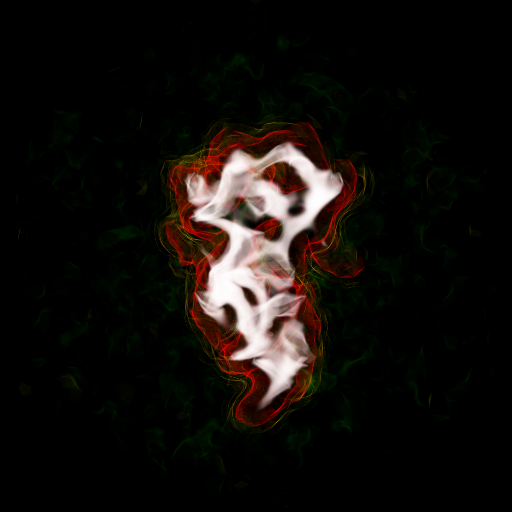

In [32]:
latents_intrp = interp(decoder.latents[0].cpu().detach(), decoder.latents[1].cpu().detach(), 10)


for i, l in enumerate(latents_intrp):
    field = reconstructed = decoder.predict(torch.FloatTensor(l).cuda())
    field = field.cpu().detach().squeeze(-1)
    plot_field(field[:, :, :, 0]).show()